算术平均 Arithmetic Mean
$$
\bar{x} = \mu = \frac{1}{n}\sum_{i=1}^n x_i
$$


In [1]:
import numpy as np

data = np.array([1, 2, 3, 4, 5, 4, 3, 2, 1])

arithmetic_mean = data.mean()
print(f'算术平均值 = {arithmetic_mean}')


算术平均值 = 2.7777777777777777


几何平均 Geometric Mean
$$
\bar{x} = (\prod_{i=1}^n x_i)^{\frac{1}{n}}
$$

In [2]:
geometric_mean = data.prod() ** (1 / data.size)
print(f'几何平均 = {geometric_mean}')


几何平均 = 2.423131275401765


$$
\text{方差 (Variance): 统计量, 用于衡量数据点与数据均值之间的差异程度} \\
\sigma^2 = \dfrac{1}{n} \sum_{i=1}^n (x_i - \mu)^2 \\
\quad \\
\mu \text{ 是总体的均值} \\
\quad \\
\text{样本方差 (Sample Variance): 统计量, 用于衡量样本数据点与样本均值之间的差异程度} \\
S^2 = \dfrac{1}{n-1} \sum_{i=1}^n (x_i - \bar{x})^2 \\
\quad \\
\bar{x} \text{ 是样本的均值} \\
\text{这里的-1是贝塞尔校正项 (Bessel's Correction), 样本数据仅是总体的一个子集, 它不包含所有信息} \\
\text{因此样本方差往往会低估总体方差, 为了弥补这一差异, 引入了贝塞尔校正项, 将除数从n改为n-1, 从而更准确地估计总体方差} \\
$$

In [3]:
variance = data.var()
print(f'方差 = {variance}')

sample_variance = data.var(ddof=1)
print(f'样本方差 = {sample_variance}')

方差 = 1.7283950617283952
样本方差 = 1.9444444444444446


$$
\text{正态分布的概率密度函数} \\
f(x; \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x - \mu)^2}{2\sigma^2}}
\quad \\
\mu: \text{均值} \\
\sigma^2: \text{方差} \\
\text{标准正态分布: } \mu = 0, \sigma^2 = 1
$$

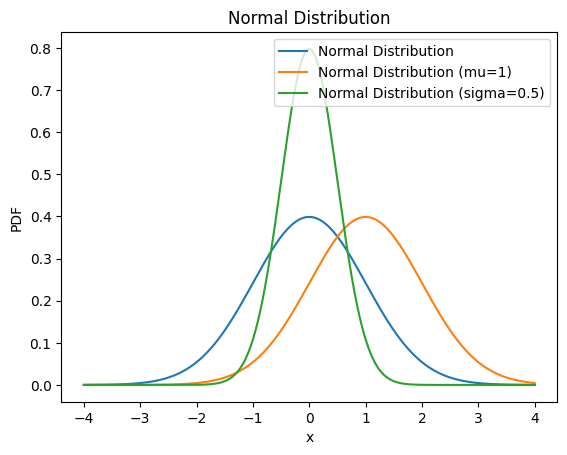

In [4]:
from matplotlib import pyplot as plt
import scipy.stats as stats
normal_distribution = stats.norm()
x = np.linspace(-4, 4, 1000)
y = normal_distribution.pdf(x)
plt.plot(x, y, label=f'Normal Distribution')
plt.xlabel('x')
plt.ylabel('PDF')
plt.title('Normal Distribution')

# adjust mu
mu = 1
normal_distribution_mu = stats.norm(loc=mu)
y = normal_distribution_mu.pdf(x)
plt.plot(x, y, label=f'Normal Distribution (mu={mu})')

# adjust sigma
sigma = 0.5
normal_distribution_sigma = stats.norm(scale=sigma)
y = normal_distribution_sigma.pdf(x)
plt.plot(x, y, label=f'Normal Distribution (sigma={sigma})')

plt.legend()
plt.show()


$$
\text{卡方分布的概率密度函数} \\
\quad \\
\chi^2(x; df=1) = \sum_{i=1}^n Z_i^2 \\
$$

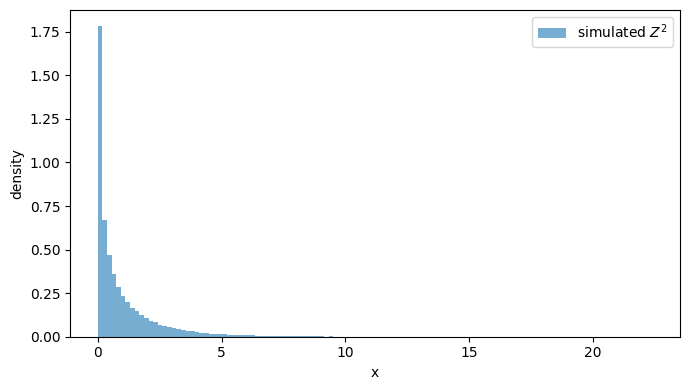

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

rng = np.random.default_rng(0)
n = 200000
z = rng.normal(0, 1, n)
x_sim = z**2  # Z^2 -> chi-square(1)

df = 1
x = np.linspace(0, chi2.ppf(0.999, df), 800)
pdf = chi2.pdf(x, df)

plt.figure(figsize=(7,4))
# plt.plot(x_sim, linewidth=2, label=r"theory $\chi^2_1$")
plt.hist(x_sim, bins=120, density=True, alpha=0.6, label="simulated $Z^2$")
# plt.ylim(0, 0.05)
# plt.plot(x, pdf, linewidth=2, label=r"theory $\chi^2_1$")
# plt.title(r"Simulation: $Z^2$ vs $\chi^2_1$")
plt.xlabel("x")
plt.ylabel("density")
plt.legend()
plt.tight_layout()
plt.show()

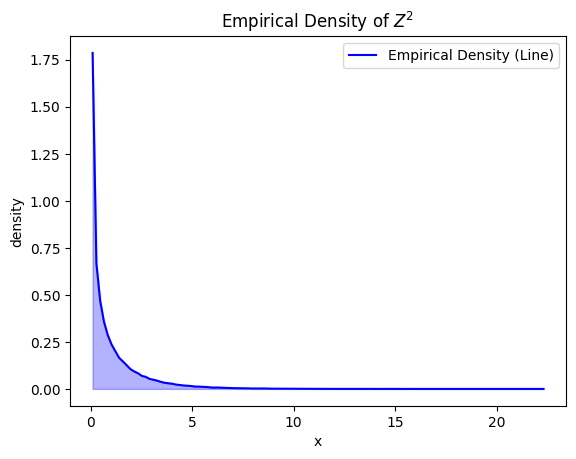

In [17]:
# 手动计算直方图和密度函数
counts, bins = np.histogram(x_sim, bins=120)
manual_density = counts / (counts.sum() * np.diff(bins))
bin_centers = (bins[:-1] + bins[1:]) / 2
plt.plot(bin_centers, manual_density, 'b-', label="Empirical Density (Line)")
plt.fill_between(bin_centers, manual_density, alpha=0.3, color='blue')
plt.title("Empirical Density of $Z^2$")
plt.xlabel("x")
plt.ylabel("density")
plt.legend()
plt.show()

$$
\text{恒等式} \\
\bar{x} = \frac{1}{n} \sum x_i \\
\sum x_i = n\bar{x} \\
\quad \\

\sum (x_i - \bar{x})^2 = \sum (x_i - \bar{x})(x_i - \bar{x}) \\
= \sum (x_i^2 - 2x_i\bar{x} + \bar{x}^2) \\
= \sum x_i^2 - \sum 2x_i\bar{x} + \sum \bar{x}^2 \\
\quad \\

\text{处理第二项} \\
\sum 2x_i\bar{x} = 2\bar{x}\sum x_i = 2n\bar{x}^2 \\
\quad \\

\text{处理第三项} \\
\sum \bar{x}^2 = n\bar{x}^2 \\
\quad \\

\text{最终结果} \\
\sum (x_i - \bar{x})^2 = \sum x_i^2 - 2n\bar{x}^2 + n\bar{x}^2 \\
= \sum x_i^2 - n\bar{x}^2 \\
= \sum x_i^2 - \frac{1}{n}(\sum x_i)^2 \\
$$

In [22]:
((data - arithmetic_mean)**2).sum() == (data**2).sum() - 1 / data.size * (data.sum()**2)


np.True_

$$
\text{协方差 Covariance: 协方差表示X, Y随机变量的变化趋势是否一致} \\
COV > 0: \text{说明X和Y正相关, 即当X增加时, Y也增加} \\
COV < 0: \text{说明X和Y负相关, 即当X增加时, Y减少} \\
COV = 0: \text{说明X和Y独立, 即X的变化不影响Y的变化} \\
COV = \frac{1}{n - 1} \sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y}) \\
\text{样本协方差计算时, 分母为n - 1. 总体协方差计算时, 分母为n.} \\ 
$$

In [27]:
x = np.array([1, 2, 3, 4, 5])
y = np.array([5, 4, 5, 7, 9])

# np.cov 给的是矩阵
# [Cov[X, X], Cov[X, Y]]
# [Cov[Y, X], Cov[Y, Y]]

sample_COV = 1 / (len(x) - 1) * np.sum((x - np.mean(x)) * (y - np.mean(y)))
sample_npCOV = np.cov(x, y, ddof=1)[0, 1]

total_COV = 1 / len(x) * np.sum((x - np.mean(x)) * (y - np.mean(y)))
total_npCOV = np.cov(x, y, ddof=0)[0, 1]

print(f'sample_COV: {sample_COV}')
print(f'sample_npCOV: {sample_npCOV}')
print(f'total_COV: {total_COV}')
print(f'total_npCOV: {total_npCOV}')


sample_COV: 2.75
sample_npCOV: 2.75
total_COV: 2.2
total_npCOV: 2.2


$$
\text{离散型随机变量的数学期望 (Expectation)} \\
E(X) = \sum_{i=1}^n x_i p(x_i) \\
\quad \\
\text{连续型随机变量的数学期望 (Expectation)} \\
E(X) = \int_{-\infty}^{\infty} x f(x) dx \\
$$

In [33]:
x = np.array([1, 2, 3, 4, 5, 6])
p = np.array([1/6, 1/6, 1/6, 1/6, 1/6, 1/6])
discret_E = np.sum(x * p)
discret_E == x.mean()

np.True_

Mathematical Expectation: 1.3333333333333335


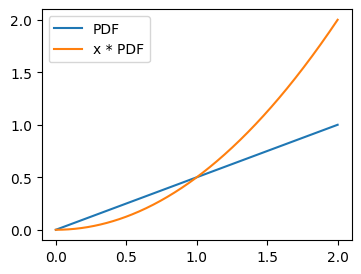

In [46]:
from scipy.integrate import quad

x = np.linspace(0, 2, 400)

# 1. 定义合法的概率密度函数 (PDF)
def f(x):
    return 0.5 * x

# 2. 定义期望的被积函数：x * f(x)
def expectation_integrand(x):
    return x * f(x)

# 3. 使用积分函数计算期望
# quad 函数返回 (积分值, 误差估计)
expected_value, error = quad(expectation_integrand, 0, 2)

print(f"Mathematical Expectation: {expected_value}") 
# 结果为 1.333... (即 4/3)
# 注意：这比区间的算术中点 1.0 更偏右，因为右侧的概率密度更大。

plt.figure(figsize=(4, 3))
plt.plot(x, f(x), label='PDF')
plt.plot(x, expectation_integrand(x), label='x * PDF')
plt.legend()
plt.show()
